In [144]:
# Check and install required libraries
required_packages <- c("readr", "dplyr", "gstat", "hydroGOF", "ggplot2", "tidyr", "lubridate", "sf", "stars")
missing_packages <- required_packages[!sapply(required_packages, requireNamespace, quietly = TRUE)]

if (length(missing_packages) > 0) {
  cat("Installing missing packages:", paste(missing_packages, collapse = ", "), "\n")
  install.packages(missing_packages, repos = "http://cran.us.r-project.org")
} else {
  cat("All required packages are already installed.\n")
}

# Load libraries, suppressing startup messages
suppressPackageStartupMessages({
  library(readr)
  library(dplyr)
  library(gstat)
  library(hydroGOF)
  library(ggplot2)
  library(tidyr)
  library(lubridate)
  library(sf)
  library(stars)
})
cat("Required libraries loaded.\n")

All required packages are already installed.
Required libraries loaded.
Required libraries loaded.


## Geospatial Statistics Mini Project

This notebook outlines the steps for the GNR 640 mini project, focusing on generating and evaluating gridded climate data products. It is a conversion from an R Markdown document.

### Step 1: Data Preparation

#### 1.1 Access and Preprocess Station Observations

Load and preprocess the station-based daily precipitation data.

[1] "Processed station data (first few rows with DUMMY coordinates):"
Simple feature collection with 6 features and 3 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -116.1325 ymin: 26.09336 xmax: -76.7482 ymax: 47.57121
Geodetic CRS:  WGS 84
# A tibble: 6 × 4
  date       station_name                precipitation             geometry
  <date>     <chr>                               <dbl>          <POINT [°]>
1 2006-01-01 AK_Fairbanks_11_NE                    0   (-109.8703 31.90186)
2 2006-01-01 AK_Sitka_1_NE                         3.8 (-101.9652 43.91932)
3 2006-01-01 AK_St._Paul_4_NE                      0   (-113.5308 34.81545)
4 2006-01-01 AK_Utqia?vik_formerly_Barr…           0    (-76.7482 46.19242)
5 2006-01-01 AL_Gadsden_19_N                       0   (-116.1325 47.57121)
6 2006-01-01 AL_Selma_13_WNW                       1.6 (-78.40172 26.09336)
Simple feature collection with 6 features and 3 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmi

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   2.395   0.500 461.700 

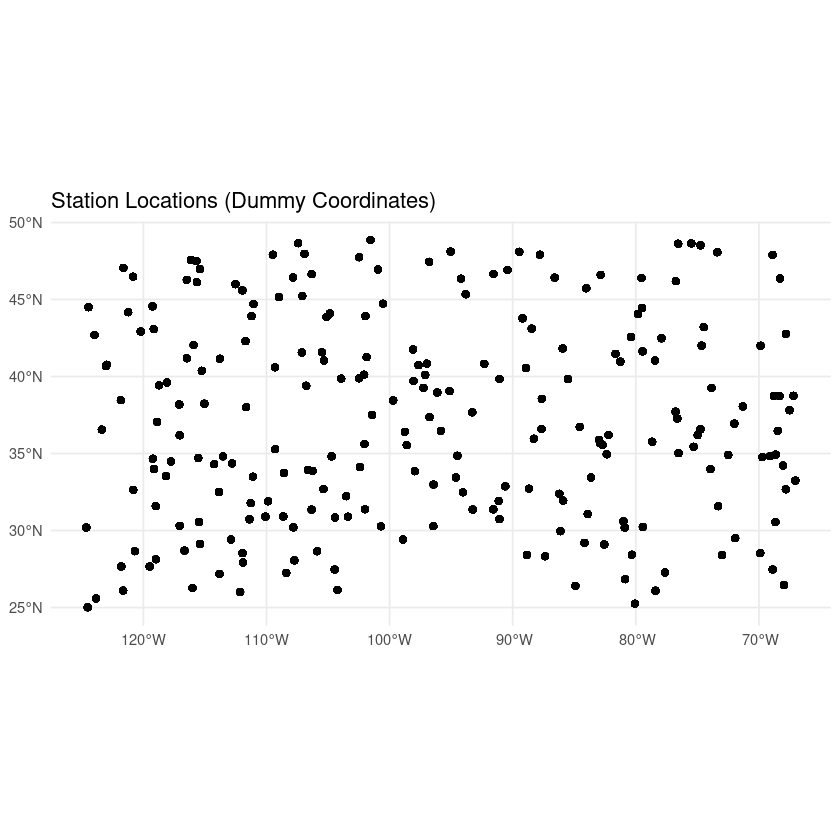

In [145]:
# Define station data file path
station_data_path <- "data/USCRN_Daily_Precipitation.csv"

# Load station data
station_data <- readr::read_csv(station_data_path, show_col_types = FALSE)

# Preprocess station data
# Convert 'date' to Date objects (handles potential time components)
station_data$date <- mdy_hms(station_data$date) 
station_data$date <- as.Date(station_data$date)

# Reshape data to long format (one station observation per row) and remove rows with NA precipitation
station_data_long <- station_data %>%
  pivot_longer(cols = -date, names_to = "station_name", values_to = "precipitation") %>%
  filter(!is.na(precipitation))

# Add station coordinates (latitude/longitude)
# IMPORTANT: The USCRN_Daily_Precipitation.csv does not contain lat/lon.
# DEMO: Create DUMMY station coordinates. REPLACE with actual station metadata.
station_names_unique <- unique(station_data_long$station_name)
set.seed(123) # for reproducibility
station_metadata_dummy <- data.frame(
  station_name = station_names_unique,
  # Approximate bounding box for continental USA: Lon: -125 to -67, Lat: 25 to 49
  latitude = runif(length(station_names_unique), min = 25, max = 49),
  longitude = runif(length(station_names_unique), min = -125, max = -67)
)

# Join station data with coordinates and filter out stations without coordinates
station_data_processed <- station_data_long %>%
  left_join(station_metadata_dummy, by = "station_name") %>%
  filter(!is.na(latitude) & !is.na(longitude))

# Convert to sf object for spatial analysis, ensuring no NA coordinates
station_data_sf <- station_data_processed %>%
  filter(!is.na(longitude) & !is.na(latitude)) %>%
  st_as_sf(coords = c("longitude", "latitude" ), crs = 4326) # WGS84 CRS

print("Processed station data (first few rows with DUMMY coordinates):")
print(head(station_data_sf))
summary(station_data_sf$precipitation)

# Plot station locations
if (nrow(station_data_sf) > 0) {
  print(ggplot() + geom_sf(data = station_data_sf) + ggtitle("Station Locations (Dummy Coordinates)") + theme_minimal())
} else { print("No station data to plot.")}

#### 1.2 Extract Satellite Estimates

Load and preprocess global and U.S.-specific satellite-derived daily data.

In [146]:
# Define satellite data file paths
global_satellite_data_path <- "data/Global_Satellite_Daily_Data.csv"
us_satellite_data_path <- "data/US_Satellite_Daily_Data.csv"

# Load satellite data
global_satellite_data_raw <- readr::read_csv(global_satellite_data_path, show_col_types = FALSE)
us_satellite_data_raw <- readr::read_csv(us_satellite_data_path, show_col_types = FALSE)

# Preprocess US Satellite Data
# Reshape US satellite data to long format
us_satellite_long <- us_satellite_data_raw %>%
  pivot_longer(cols = -c(latitude, longitude), 
               names_to = "date_str", 
               values_to = "satellite_precipitation") %>%
  mutate(date = as.Date(date_str, format="%d-%m-%Y")) %>% # Convert date string (DD-MM-YYYY) to Date object
  filter(!is.na(date)) # Filter out rows where date parsing failed

# Filter US satellite data from 2024-01-01 onwards and select relevant columns
us_satellite_processed <- us_satellite_long %>%
  filter(date >= as.Date("2024-01-01")) %>%
  select(latitude, longitude, date, satellite_precipitation) %>%
  filter(!is.na(satellite_precipitation))

# Convert US satellite data to sf object (WGS84 CRS)
us_satellite_sf <- us_satellite_processed %>%
  filter(!is.na(longitude) & !is.na(latitude)) %>%
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326)

print("Processed U.S. Satellite Data (first few rows):")
print(head(us_satellite_sf))
summary(us_satellite_sf$satellite_precipitation)

# Preprocess Global Satellite Data (Optional - for US region)
# This section demonstrates filtering global data for the US extent if needed.
# The project primarily uses 'US_Satellite_Daily_Data.csv'.
usa_bbox <- st_bbox(c(xmin = -125, ymin = 24, xmax = -66, ymax = 50), crs = st_crs(4326))

global_satellite_us_filtered_sf <- global_satellite_data_raw %>%
  pivot_longer(cols = -c(latitude, longitude), 
               names_to = "date_str", 
               values_to = "satellite_precipitation") %>%
  mutate(date = as.Date(date_str, format="%d-%m-%Y")) %>% # Convert date string (DD-MM-YYYY)
  filter(date >= as.Date("2024-01-01")) %>%
  select(latitude, longitude, date, satellite_precipitation) %>%
  filter(!is.na(satellite_precipitation) & 
         longitude >= usa_bbox[["xmin"]] & longitude <= usa_bbox[["xmax"]] & 
         latitude >= usa_bbox[["ymin"]] & latitude <= usa_bbox[["ymax"]]) %>%
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326)

print("Processed Global Satellite Data filtered for US (first few rows):")
if (nrow(global_satellite_us_filtered_sf) > 0) {
  print(head(global_satellite_us_filtered_sf))
  summary(global_satellite_us_filtered_sf$satellite_precipitation)
} else {
  print("No global satellite data points found within the USA bounding box after filtering.")
}

# 'us_satellite_sf' will be the primary satellite reference.
# 'station_data_sf' will be used for interpolation and direct comparison.

[1] "Processed U.S. Satellite Data (first few rows):"
Simple feature collection with 6 features and 2 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -80.75 ymin: 25 xmax: -80.75 ymax: 25
Geodetic CRS:  WGS 84
# A tibble: 6 × 3
  date       satellite_precipitation    geometry
  <date>                       <dbl> <POINT [°]>
1 2024-01-01                0        (-80.75 25)
2 2024-01-02                0        (-80.75 25)
3 2024-01-03                0        (-80.75 25)
4 2024-01-04                0.000264 (-80.75 25)
5 2024-01-05                0.000430 (-80.75 25)
6 2024-01-06                0.00421  (-80.75 25)
Simple feature collection with 6 features and 2 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -80.75 ymin: 25 xmax: -80.75 ymax: 25
Geodetic CRS:  WGS 84
# A tibble: 6 × 3
  date       satellite_precipitation    geometry
  <date>                       <dbl> <POINT [°]>
1 2024-01-01                0        (-80.75 25)
2 2024-01-02         

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000000 0.0000000 0.0002828 0.0085355 0.0051970 0.8690362 

[1] "Processed Global Satellite Data filtered for US (first few rows):"
Simple feature collection with 6 features and 2 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -125 ymin: 24 xmax: -125 ymax: 24
Geodetic CRS:  WGS 84
# A tibble: 6 × 3
  date       satellite_precipitation    geometry
  <date>                       <dbl> <POINT [°]>
1 2024-01-01                0.00148    (-125 24)
2 2024-01-02                0.00124    (-125 24)
3 2024-01-03                0.00132    (-125 24)
4 2024-01-04                0.00122    (-125 24)
5 2024-01-05                0.000877   (-125 24)
6 2024-01-06                0.00588    (-125 24)
Simple feature collection with 6 features and 2 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -125 ymin: 24 xmax: -125 ymax: 24
Geodetic CRS:  WGS 84
# A tibble: 6 × 3
  date       satellite_precipitation    geometry
  <date>                       <dbl> <POINT [°]>
1 2024-01-01                0.00148    (-125 24)
2 2024-01-0

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000000 0.000505 0.009470 0.005981 1.069154 

### Step 2: Interpolation

Apply spatial interpolation techniques (IDW, Kriging) to station observations to generate gridded precipitation data.

In [147]:
# Check if processed station data (station_data_sf) exists
if (!exists("station_data_sf") || nrow(station_data_sf) == 0) {
  stop("Station data (station_data_sf) not available or empty. Please run Step 1 first.")
}

# Define interpolation grid (2-degree resolution for approximate continental USA)
lon_range <- c(-125, -67)
lat_range <- c(25, 49)
cell_size <- 2 # Two-degree resolution

# Create template grid using 'stars' package
grid_template_stars <- st_as_stars(
  st_bbox(c(xmin = lon_range[1], ymin = lat_range[1], xmax = lon_range[2], ymax = lat_range[2]), 
          crs = st_crs(4326)), 
  dx = cell_size, 
  dy = cell_size
)

# Get unique, sorted dates from station data
station_data_sf$date <- as.Date(station_data_sf$date)
all_unique_dates <- unique(station_data_sf$date)
all_unique_dates <- sort(all_unique_dates)

# Filter dates: process up to 'max_days_to_process' most recent days from year 2020
dates_in_2020 <- all_unique_dates[format(all_unique_dates, "%Y") == "2020"]
max_days_to_process <- 100 
dates_to_process <- tail(dates_in_2020, max_days_to_process)

# Initialize lists for daily interpolated rasters and station predictions
daily_interpolated_stars_list <- list()
daily_station_predictions_list <- list()
sample_variogram_empirical <- NULL # To store a sample empirical variogram
sample_variogram_fitted <- NULL   # To store a sample fitted variogram model
sample_variogram_day <- NULL      # To store the day of the sample variogram

print(paste("Starting daily interpolation for up to", length(dates_to_process), "days from 2020..."))

if (length(dates_to_process) > 0) {
  print(paste("First date to process:", min(dates_to_process)))
  print(paste("Last date to process:", max(dates_to_process)))
  
  station_data_for_period <- station_data_sf %>% filter(date %in% dates_to_process)
  print("Summary of 'precipitation' in 'station_data_sf' for selected dates:")
  if (nrow(station_data_for_period) > 0) print(summary(station_data_for_period$precipitation))
  else print("No station data found for the selected dates.")
} else {
  print("No dates selected for processing.")
}

# Loop through each selected date for interpolation
for (i in 1:length(dates_to_process)) {
  current_date <- dates_to_process[i]
  current_date_char <- as.character(current_date)
  print(paste0("Processing day ", i, "/", length(dates_to_process), ": ", current_date_char))
  
  single_day_data_loop <- station_data_sf %>% filter(date == current_date)
  print("Summary of precipitation for current day being processed:")
  print(summary(single_day_data_loop$precipitation))

  if (nrow(single_day_data_loop) < 3) {
    print(paste("Skipping day", current_date_char, ": Not enough data points (found", nrow(single_day_data_loop), ")."))
    daily_interpolated_stars_list[[current_date_char]] <- NULL
    daily_station_predictions_list[[current_date_char]] <- NULL
    next
  }

  # Perform IDW interpolation
  idw_interpolation_daily <- tryCatch({
    gstat::idw(formula = precipitation ~ 1, locations = single_day_data_loop, newdata = grid_template_stars, idp = 2.0)
  }, error = function(e) { print(paste("IDW Error for", current_date_char, ":", e$message)); NULL })
  if (!is.null(idw_interpolation_daily)) { 
      names(idw_interpolation_daily)[1] <- "idw_pred" 
      print(paste("IDW interpolation successful for", current_date_char))
  } else { print(paste("IDW interpolation failed or resulted in NULL for", current_date_char)) }
  
  # Perform Ordinary Kriging interpolation
  # Variogram fitting can issue warnings (e.g., singular model). Script attempts fitting, uses default on failure.
  kriging_interpolation_daily <- NULL
  if(nrow(single_day_data_loop) > 5) { # Need sufficient points for variogram
    variogram_model_daily <- tryCatch({ gstat::variogram(precipitation ~ 1, data = single_day_data_loop) }, error = function(e) {NULL})
    
    if (!is.null(variogram_model_daily)){
        fitted_variogram_daily <- tryCatch({
            gstat::fit.variogram(variogram_model_daily, model = vgm(psill = mean(variogram_model_daily$gamma, na.rm=TRUE), model = "Sph", range = max(variogram_model_daily$dist, na.rm=TRUE)/2, nugget = min(variogram_model_daily$gamma, na.rm=TRUE)))
        }, error = function(e) {NULL})
        
        # Store the first valid variogram for plotting later
        if (is.null(sample_variogram_empirical) && !is.null(variogram_model_daily) && !is.null(fitted_variogram_daily)) {
            sample_variogram_empirical <- variogram_model_daily
            sample_variogram_fitted <- fitted_variogram_daily
            sample_variogram_day <- current_date_char
        }
        
        # Fallback to a default variogram if fitting fails or model is invalid
        if (is.null(fitted_variogram_daily) || any(is.na(fitted_variogram_daily$psill)) || (length(fitted_variogram_daily$psill) > 1 && fitted_variogram_daily$psill[2] <= 0)) { 
            print(paste("Variogram fitting failed for", current_date_char, ". Using default variogram."))
            mean_precip <- mean(single_day_data_loop$precipitation, na.rm=TRUE); min_precip <- min(single_day_data_loop$precipitation, na.rm=TRUE)
            max_dist <- if(nrow(single_day_data_loop) > 1) max(dist(st_coordinates(single_day_data_loop)), na.rm=TRUE) else 100
            fitted_variogram_daily <- vgm(psill = ifelse(is.na(mean_precip) || mean_precip == 0 || !is.finite(mean_precip), 1, abs(mean_precip/2) + 0.001), model = "Sph", range = ifelse(is.na(max_dist) || max_dist <= 0 || !is.finite(max_dist), 10, max_dist/3), nugget = ifelse(is.na(min_precip) || !is.finite(min_precip), 0.1, abs(min_precip/2)))
            if(length(fitted_variogram_daily$psill) > 1 && (fitted_variogram_daily$psill[2] <=0 || is.na(fitted_variogram_daily$psill[2]))) fitted_variogram_daily$psill[2] = 0.001
            if(length(fitted_variogram_daily$range) > 1 && (fitted_variogram_daily$range[2] <=0 || is.na(fitted_variogram_daily$range[2]))) fitted_variogram_daily$range[2] = 0.001
            if(length(fitted_variogram_daily$psill) == 1 && (fitted_variogram_daily$psill[1] <=0 || is.na(fitted_variogram_daily$psill[1]))) fitted_variogram_daily$psill[1] = 0.001
        }
        
        kriging_interpolation_daily <- tryCatch({
            gstat::krige(formula = precipitation ~ 1, locations = single_day_data_loop, newdata = grid_template_stars, model = fitted_variogram_daily)
        }, error = function(e) { print(paste("Kriging Error for", current_date_char, ":", e$message)); NULL })
        if (!is.null(kriging_interpolation_daily)) { 
            names(kriging_interpolation_daily)[1] <- "kriging_pred"; if(length(names(kriging_interpolation_daily)) > 1) names(kriging_interpolation_daily)[2] <- "kriging_var" 
            print(paste("Kriging interpolation successful for", current_date_char))
        } else { print(paste("Kriging interpolation failed or resulted in NULL for", current_date_char)) }
    } else { print(paste("Could not compute variogram for", current_date_char, "(e.g., too few unique locations). Kriging skipped.")) }
  } else { print(paste("Skipping Kriging for", current_date_char, ": insufficient data points for variogram.")) }

  # Store daily IDW and Kriging results (use NA grid if interpolation failed)
  if (is.null(idw_interpolation_daily)) { idw_interpolation_daily <- grid_template_stars; idw_interpolation_daily$idw_pred <- NA_real_ }
  if (is.null(kriging_interpolation_daily)) { kriging_interpolation_daily <- grid_template_stars; kriging_interpolation_daily$kriging_pred <- NA_real_; kriging_interpolation_daily$kriging_var <- NA_real_ }
  daily_interpolated_stars_list[[current_date_char]] <- c(idw_interpolation_daily, kriging_interpolation_daily)
  
  # Extract interpolated values at station locations for validation
  if (nrow(single_day_data_loop) > 0) {
    if ("idw_pred" %in% names(idw_interpolation_daily) && !all(is.na(idw_interpolation_daily$idw_pred))){
        idw_at_stations_daily <- st_extract(idw_interpolation_daily["idw_pred"], at = single_day_data_loop)
        single_day_data_loop$idw_pred_at_station <- idw_at_stations_daily$idw_pred
        print(paste("IDW values extracted at station locations for", current_date_char))
    } else { 
        single_day_data_loop$idw_pred_at_station <- NA_real_
        print(paste("IDW values NOT extracted at station locations for", current_date_char, "(IDW grid missing or all NA)."))
    }
    if ("kriging_pred" %in% names(kriging_interpolation_daily) && !all(is.na(kriging_interpolation_daily$kriging_pred))){
        kriging_at_stations_daily <- st_extract(kriging_interpolation_daily["kriging_pred"], at = single_day_data_loop)
        single_day_data_loop$kriging_pred_at_station <- kriging_at_stations_daily$kriging_pred
        print(paste("Kriging values extracted at station locations for", current_date_char))
    } else { 
        single_day_data_loop$kriging_pred_at_station <- NA_real_
        print(paste("Kriging values NOT extracted at station locations for", current_date_char, "(Kriging grid missing or all NA)."))
    }
  }
  daily_station_predictions_list[[current_date_char]] <- single_day_data_loop
}
print("Finished daily interpolations.")

# Clean up old/temporary single-day variables
if(exists("single_day_data")) rm(single_day_data); if(exists("idw_interpolation")) rm(idw_interpolation)
if(exists("kriging_interpolation")) rm(kriging_interpolation); if(exists("interpolated_results_single_day")) rm(interpolated_results_single_day)

# Print summary of first processed day's results (if available)
if (length(daily_interpolated_stars_list) > 0 && !is.null(daily_interpolated_stars_list[[1]])){
  print("Summary of gridded interpolation for the first processed day:")
  print(daily_interpolated_stars_list[[1]])
  if (length(daily_station_predictions_list) > 0 && !is.null(daily_station_predictions_list[[1]])){
      print("Summary of station predictions for the first processed day:")
      print(head(st_drop_geometry(daily_station_predictions_list[[1]][, c("station_name", "precipitation", "idw_pred_at_station", "kriging_pred_at_station")])))
  }
} else { print("No daily interpolation results to show summary for.") }

[1] "Starting daily interpolation for up to 100 days from 2020..."
[1] "First date to process: 2020-09-23"
[1] "Last date to process: 2020-12-31"
[1] "Summary of 'precipitation' in 'station_data_sf' for selected dates:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   2.487   0.400 187.500 
[1] "First date to process: 2020-09-23"
[1] "Last date to process: 2020-12-31"
[1] "Summary of 'precipitation' in 'station_data_sf' for selected dates:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   2.487   0.400 187.500 
[1] "Processing day 1/100: 2020-09-23"
[1] "Summary of precipitation for current day being processed:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   4.474   0.200 187.500 
[inverse distance weighted interpolation]
[1] "IDW interpolation successful for 2020-09-23"
[1] "Processing day 1/100: 2020-09-23"
[1] "Summary of precipitation for current day being processed:"
   Min. 1st Qu.  Median    Mean 3rd

Warning message in gstat::fit.variogram(variogram_model_daily, model = vgm(psill = mean(variogram_model_daily$gamma, :
“linear model has singular covariance matrix”
Warning message in gstat::fit.variogram(variogram_model_daily, model = vgm(psill = mean(variogram_model_daily$gamma, :
“singular model in variogram fit”
Warning message in fit.variogram(object, model, fit.sills = fit.sills, fit.ranges = fit.ranges, :
“singular model in variogram fit”
Warning message in gstat::fit.variogram(variogram_model_daily, model = vgm(psill = mean(variogram_model_daily$gamma, :
“singular model in variogram fit”
Warning message in fit.variogram(object, model, fit.sills = fit.sills, fit.ranges = fit.ranges, :
“singular model in variogram fit”


[using ordinary kriging]
[1] "Kriging interpolation successful for 2020-09-23"
[1] "IDW values extracted at station locations for 2020-09-23"
[1] "Kriging values extracted at station locations for 2020-09-23"
[1] "Processing day 2/100: 2020-09-24"
[1] "Summary of precipitation for current day being processed:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   5.737   3.400 118.400 
[inverse distance weighted interpolation]
[1] "IDW interpolation successful for 2020-09-24"
[using ordinary kriging]
[1] "Kriging interpolation successful for 2020-09-24"
[1] "IDW values extracted at station locations for 2020-09-24"
[1] "Kriging values extracted at station locations for 2020-09-24"
[1] "Processing day 3/100: 2020-09-25"
[1] "Summary of precipitation for current day being processed:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   2.338   0.500  52.800 
[inverse distance weighted interpolation]
[1] "IDW interpolation successful for 2020-09-

Warning message in gstat::fit.variogram(variogram_model_daily, model = vgm(psill = mean(variogram_model_daily$gamma, :
“No convergence after 200 iterations: try different initial values?”
Warning message in fit.variogram(object, model, fit.sills = fit.sills, fit.ranges = fit.ranges, :
“singular model in variogram fit”
Warning message in fit.variogram(object, model, fit.sills = fit.sills, fit.ranges = fit.ranges, :
“singular model in variogram fit”


[1] "Variogram fitting failed for 2020-09-25 . Using default variogram."
[using ordinary kriging]
[1] "Kriging interpolation successful for 2020-09-25"
[1] "IDW values extracted at station locations for 2020-09-25"
[1] "Kriging values extracted at station locations for 2020-09-25"
[1] "Processing day 4/100: 2020-09-26"
[1] "Summary of precipitation for current day being processed:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   1.146   0.000  36.300 
[inverse distance weighted interpolation]
[1] "IDW interpolation successful for 2020-09-26"


...

[1] "Variogram fitting failed for 2020-12-29 . Using default variogram."
[using ordinary kriging]
[1] "Kriging interpolation successful for 2020-12-29"
[1] "IDW values extracted at station locations for 2020-12-29"
[1] "Kriging values extracted at station locations for 2020-12-29"
[1] "Processing day 99/100: 2020-12-30"
[1] "Summary of precipitation for current day being processed:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   3.715   1.700  93.800 
[inverse distance weighted interpolation]
[1] "IDW interpolation successful for 2020-12-30"


Warning message in fit.variogram(object, model, fit.sills = fit.sills, fit.ranges = fit.ranges, :
“singular model in variogram fit”


[1] "Variogram fitting failed for 2020-12-30 . Using default variogram."
[using ordinary kriging]
[1] "Kriging interpolation successful for 2020-12-30"
[1] "IDW values extracted at station locations for 2020-12-30"
[1] "Kriging values extracted at station locations for 2020-12-30"
[1] "Processing day 100/100: 2020-12-31"
[1] "Summary of precipitation for current day being processed:"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.200   4.005   3.300  61.100 
[inverse distance weighted interpolation]
[1] "IDW interpolation successful for 2020-12-31"


Warning message in gstat::fit.variogram(variogram_model_daily, model = vgm(psill = mean(variogram_model_daily$gamma, :
“No convergence after 200 iterations: try different initial values?”


[using ordinary kriging]
[1] "Kriging interpolation successful for 2020-12-31"
[1] "IDW values extracted at station locations for 2020-12-31"
[1] "Kriging values extracted at station locations for 2020-12-31"
[1] "Finished daily interpolations."
[1] "Summary of gridded interpolation for the first processed day:"
stars object with 2 dimensions and 4 attributes
attribute(s):
                     Min.    1st Qu.    Median       Mean    3rd Qu.      Max.
idw_pred       0.03068055   1.358675   2.55009   4.159378   5.104218  73.44231
var1.var               NA         NA        NA        NaN         NA        NA
kriging_pred   0.54821492   4.459680   4.45968   4.375652   4.459680  15.43444
kriging_var   97.90521928 417.908366 417.90837 406.818847 417.908366 417.90837
              NA's
idw_pred         0
var1.var       348
kriging_pred     0
kriging_var      0
dimension(s):
  from to offset delta refsys x/y
x    1 29   -125     2 WGS 84 [x]
y    1 12     49    -2 WGS 84 [y]
[1] "Summary of st

#### 2.2 Visualize Interpolated Grids

Plot the IDW and Kriging interpolated precipitation grids for a sample processed day.

[1] "Plotting interpolated grids for day: 2020-09-23"


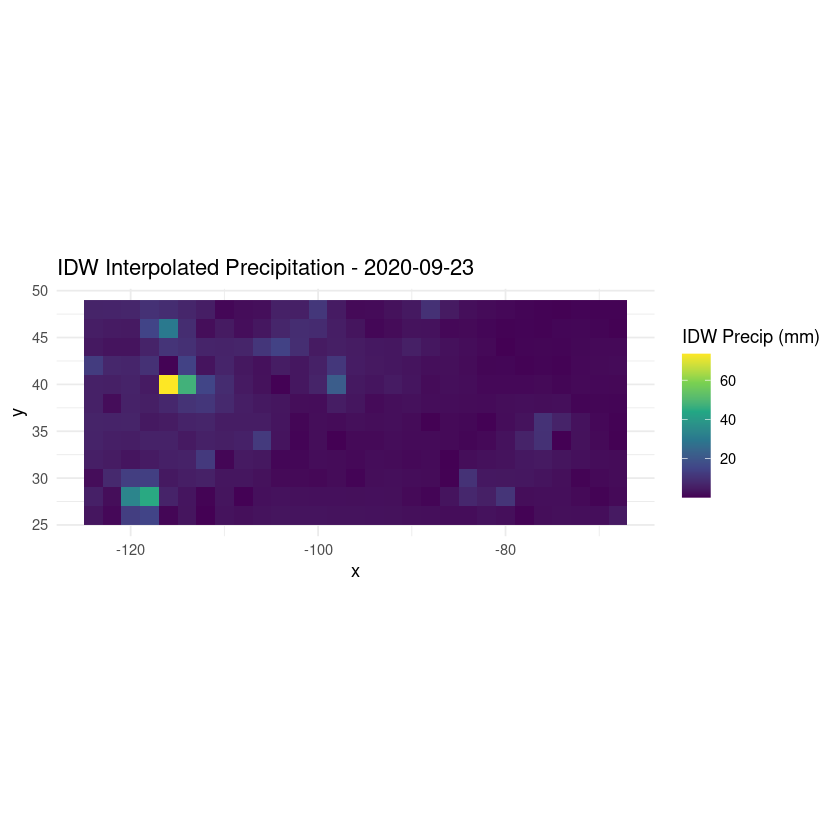

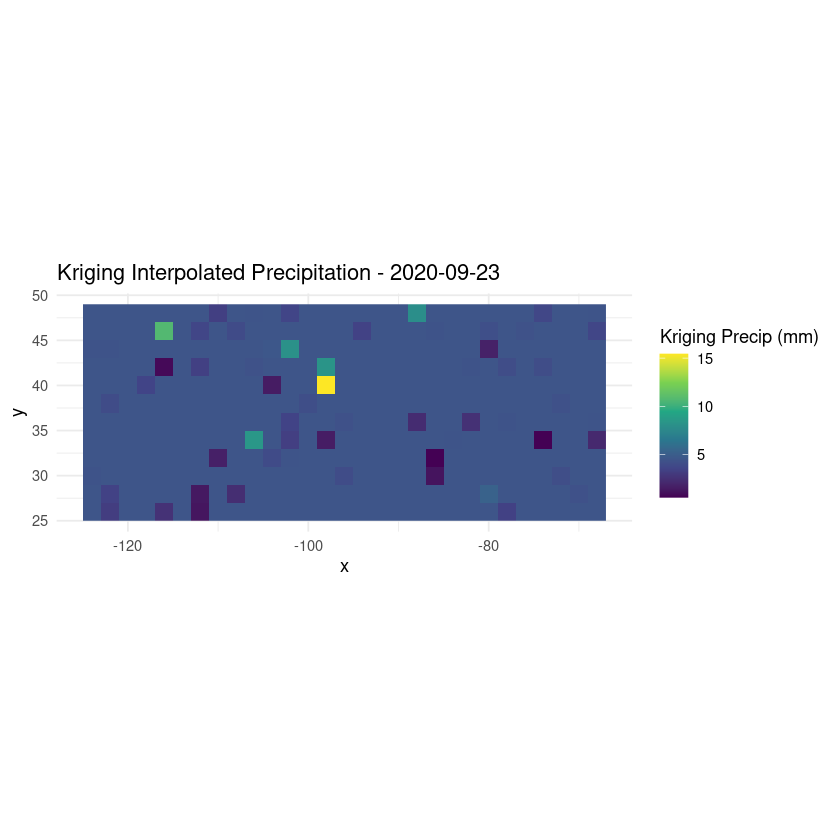

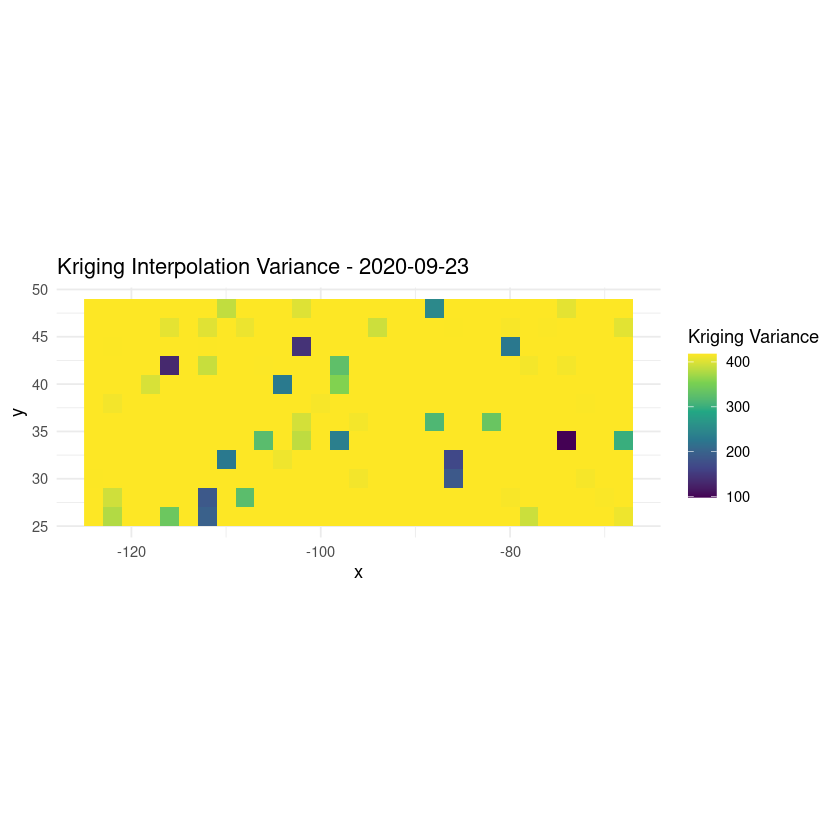

In [148]:
# Visualize the first successfully processed day's interpolated grids
if (exists("daily_interpolated_stars_list") && length(daily_interpolated_stars_list) > 0) {
  first_valid_day_key <- NULL
  for (key in names(daily_interpolated_stars_list)) {
    if (!is.null(daily_interpolated_stars_list[[key]])) {
      first_valid_day_key <- key
      break
    }
  }
  
  if (!is.null(first_valid_day_key)) {
    print(paste("Plotting interpolated grids for day:", first_valid_day_key))
    interpolated_data_to_plot <- daily_interpolated_stars_list[[first_valid_day_key]]
    
    # Plot IDW Predictions
    if ("idw_pred" %in% names(interpolated_data_to_plot) && !all(is.na(interpolated_data_to_plot$idw_pred))) {
      idw_plot <- ggplot() + 
        geom_stars(data = interpolated_data_to_plot["idw_pred"]) + 
        scale_fill_viridis_c(name = "IDW Precip (mm)", na.value = "transparent") + 
        coord_equal() + 
        theme_minimal() + 
        labs(title = paste("IDW Interpolated Precipitation -", first_valid_day_key))
      print(idw_plot)
    } else { print(paste("No valid IDW data to plot for day", first_valid_day_key)) }
    
    # Plot Kriging Predictions
    if ("kriging_pred" %in% names(interpolated_data_to_plot) && !all(is.na(interpolated_data_to_plot$kriging_pred))) {
      kriging_plot <- ggplot() + 
        geom_stars(data = interpolated_data_to_plot["kriging_pred"]) + 
        scale_fill_viridis_c(name = "Kriging Precip (mm)", na.value = "transparent") +
        coord_equal() + 
        theme_minimal() + 
        labs(title = paste("Kriging Interpolated Precipitation -", first_valid_day_key))
      print(kriging_plot)
    } else { print(paste("No valid Kriging data to plot for day", first_valid_day_key)) }
    
    # Plot Kriging Variance (if available and not all NA)
    if ("kriging_var" %in% names(interpolated_data_to_plot) && !all(is.na(interpolated_data_to_plot$kriging_var))) {
      kriging_var_plot <- ggplot() + 
        geom_stars(data = interpolated_data_to_plot["kriging_var"]) + 
        scale_fill_viridis_c(name = "Kriging Variance", na.value = "transparent") +
        coord_equal() + 
        theme_minimal() + 
        labs(title = paste("Kriging Interpolation Variance -", first_valid_day_key))
      print(kriging_var_plot)
    } else { print(paste("No valid Kriging variance data to plot for day", first_valid_day_key)) }
  } else {
    print("No successfully processed days found in daily_interpolated_stars_list to plot.")
  }
} else {
  print("Interpolated data (daily_interpolated_stars_list) not available. Run interpolation step first.")
}

#### 2.3 Experiment with Models

Evaluate interpolation models by comparing their predictions against observed station data.

[1] "Combined station predictions (first few rows):"
# A tibble: 6 × 5
  date       station_name                      precipitation idw_pred_at_station
  <date>     <chr>                                     <dbl>               <dbl>
1 2020-09-23 AK_Fairbanks_11_NE                          0.3               0.722
2 2020-09-23 AK_Sitka_1_NE                               8.9               8.84 
3 2020-09-23 AK_St._Paul_4_NE                            0.7               4.21 
4 2020-09-23 AK_Utqia?vik_formerly_Barrow_4_E…           0                 0.328
5 2020-09-23 AL_Selma_13_WNW                             0                 0.363
6 2020-09-23 AZ_Elgin_5_S                                0                 1.51 
# ℹ 1 more variable: kriging_pred_at_station <dbl>


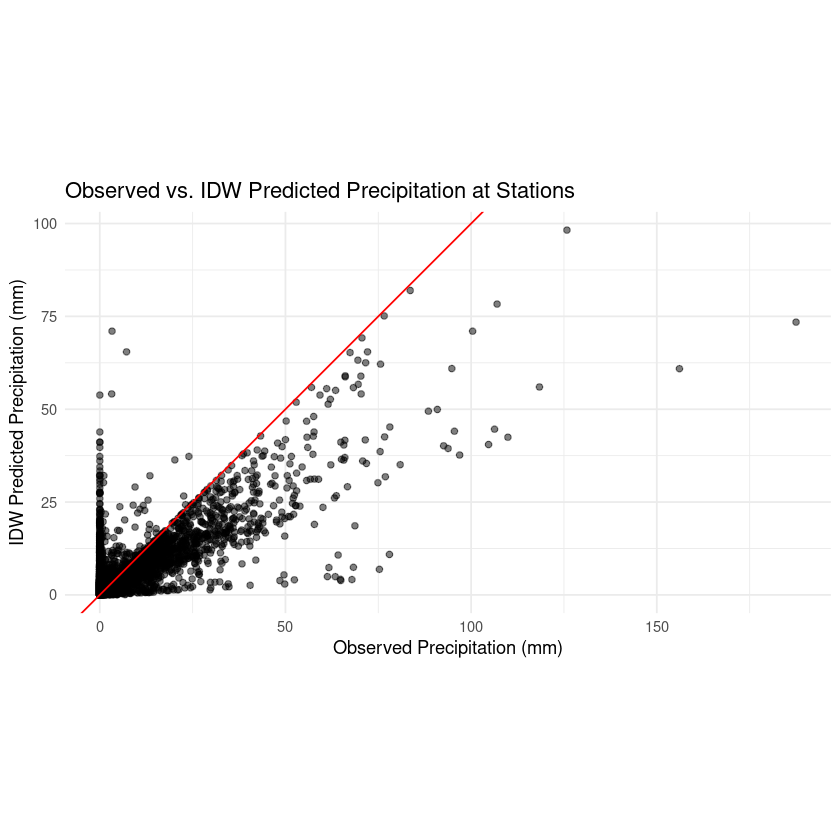

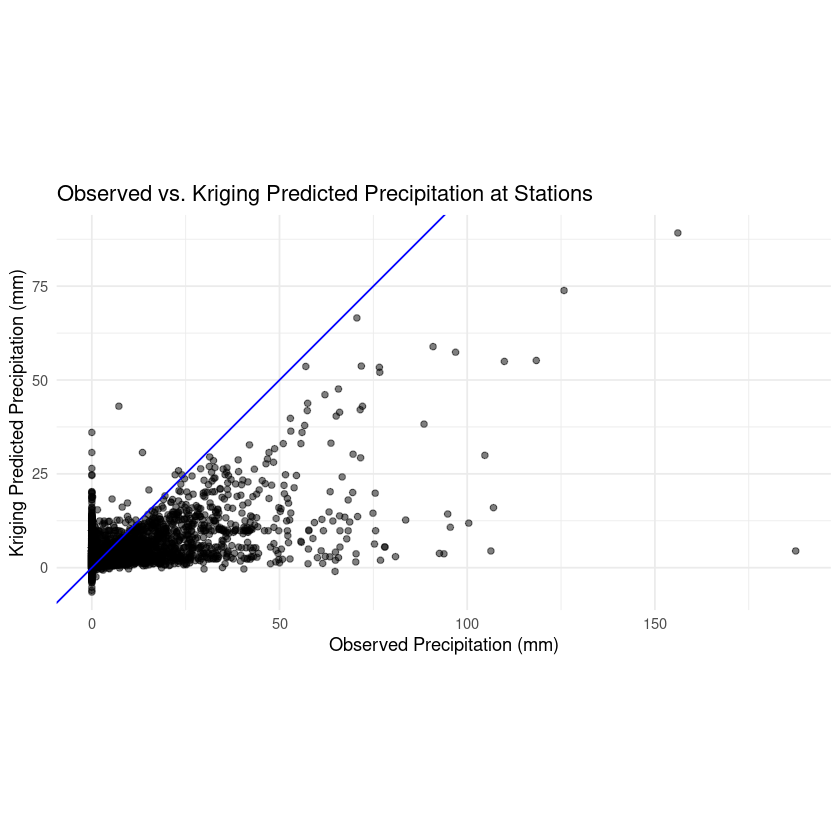

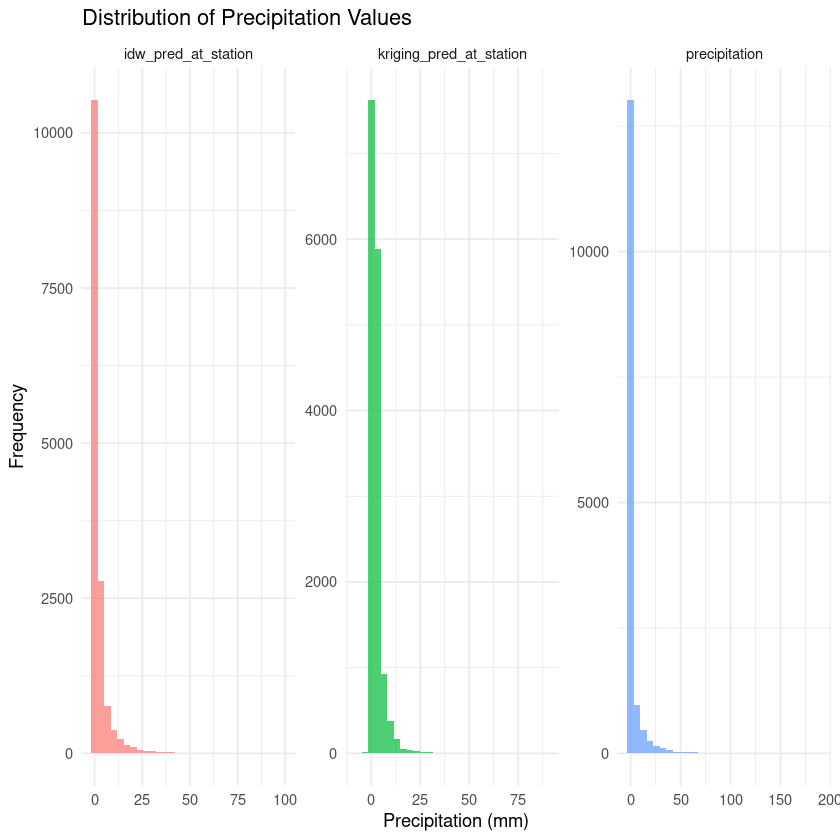

[1] "Generating time series plots for stations: SD_Aberdeen_35_WNW, TX_Austin_33_NW, CO_Boulder_14_W"


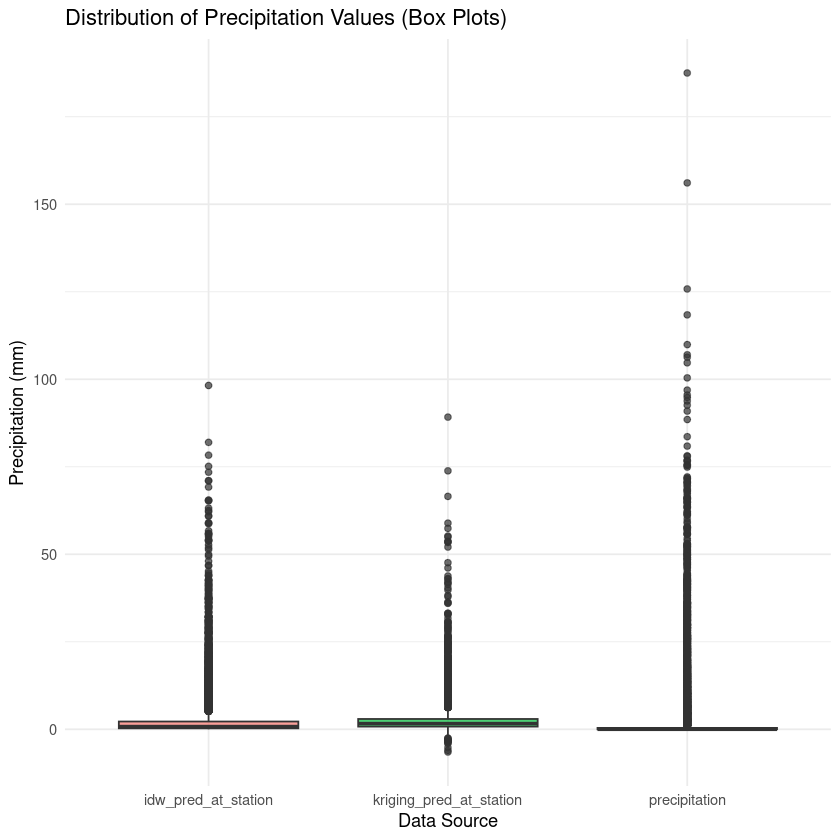

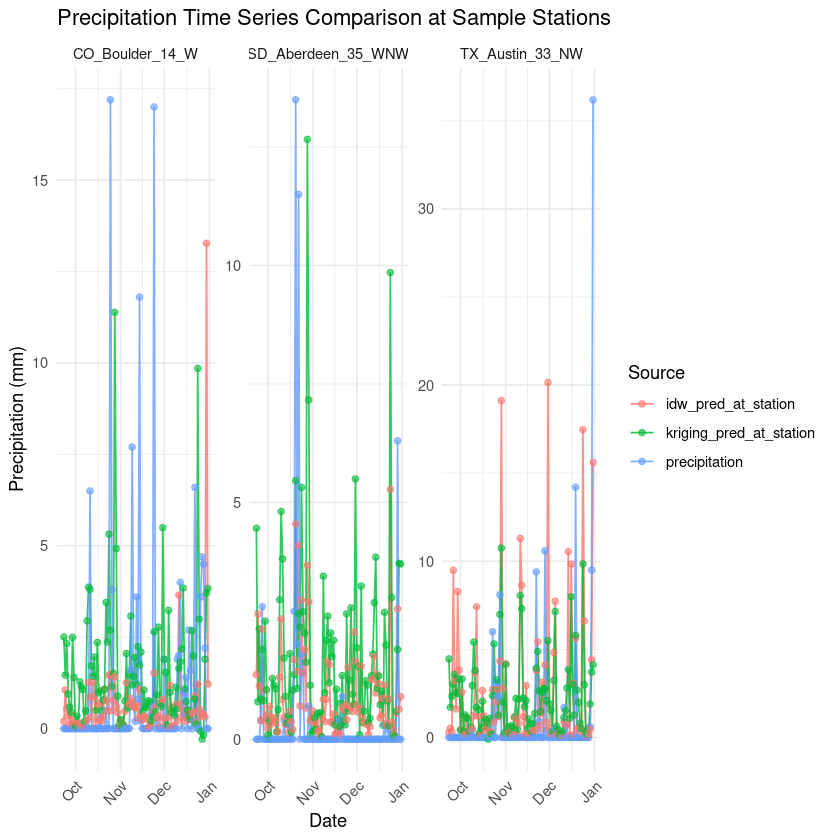

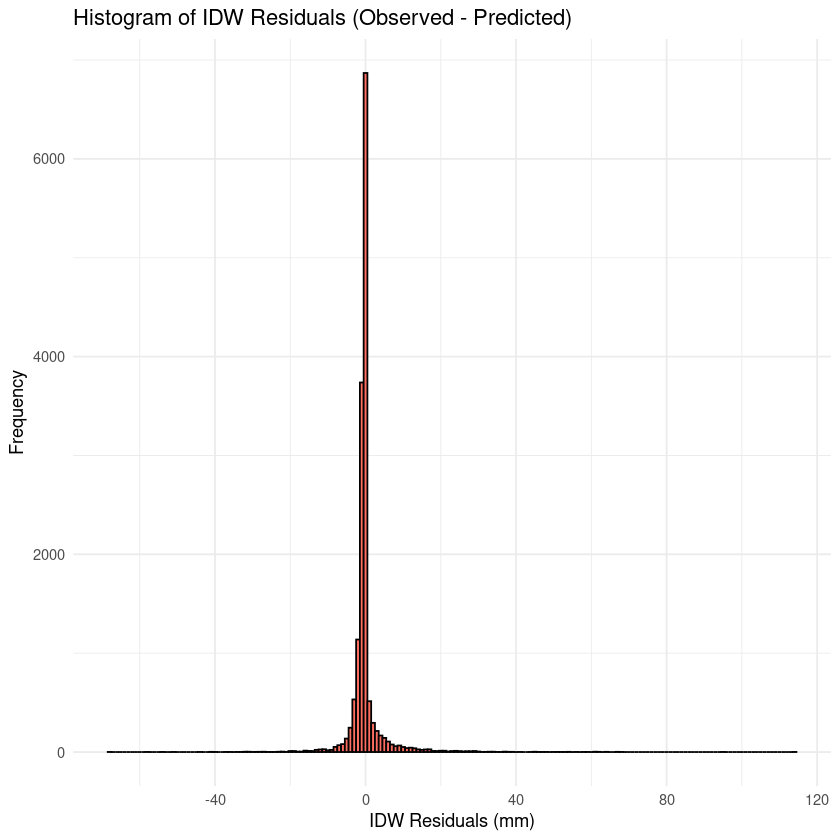

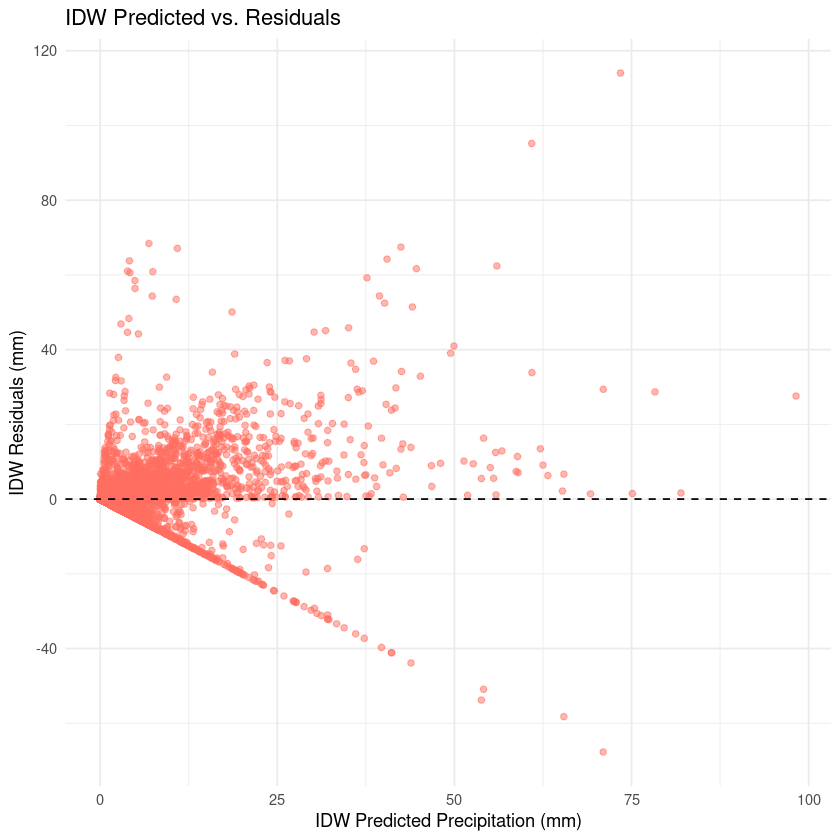

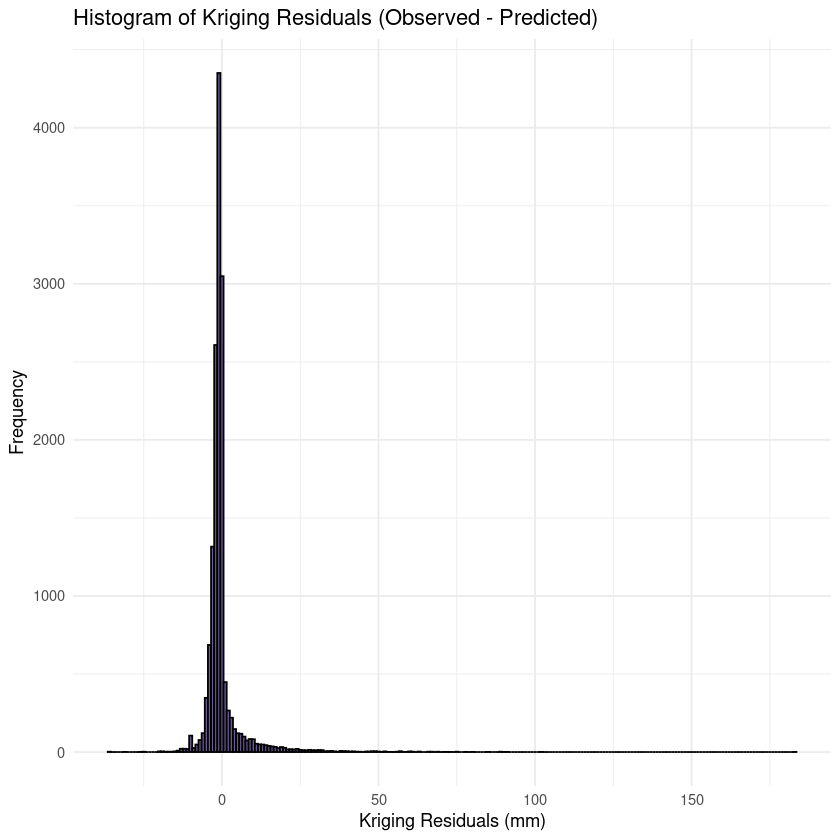

[1] "Preparing to extract satellite data at station locations..."
[1] "No satellite data or station locations for date: 18528"
[1] "No satellite data or station locations for date: 18529"
[1] "No satellite data or station locations for date: 18530"
[1] "No satellite data or station locations for date: 18531"
[1] "No satellite data or station locations for date: 18532"
[1] "No satellite data or station locations for date: 18533"
[1] "No satellite data or station locations for date: 18534"
[1] "No satellite data or station locations for date: 18535"
[1] "No satellite data or station locations for date: 18536"
[1] "No satellite data or station locations for date: 18537"
[1] "No satellite data or station locations for date: 18538"
[1] "No satellite data or station locations for date: 18539"
[1] "No satellite data or station locations for date: 18540"
[1] "No satellite data or station locations for date: 18541"
[1] "No satellite data or station locations for date: 18542"
[1] "No satellite d

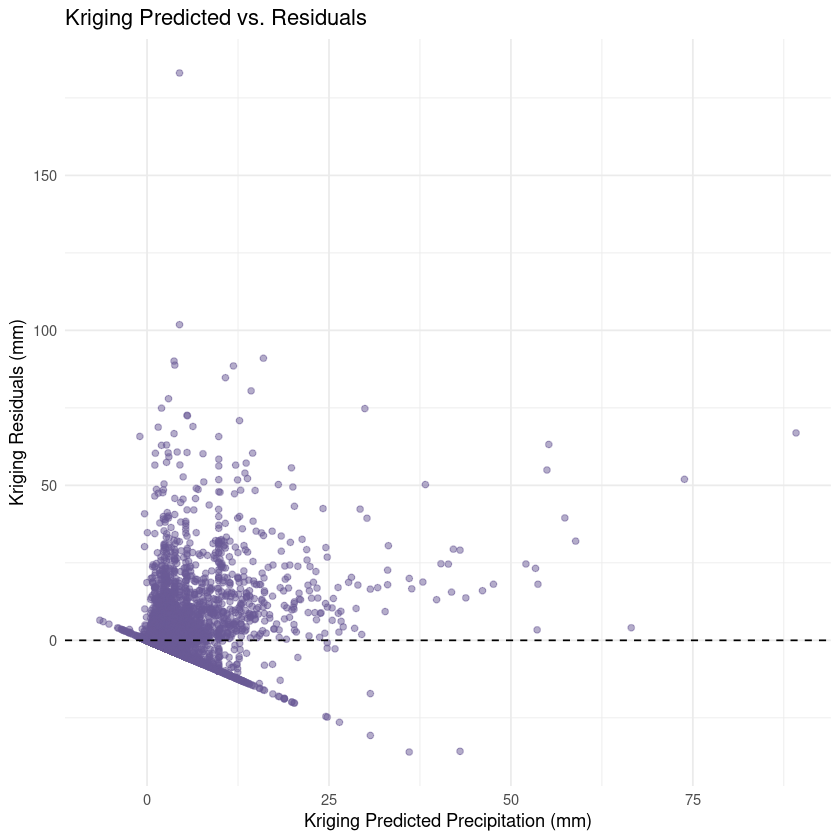

[1] "Plotting sample variogram from day: 2020-09-23"


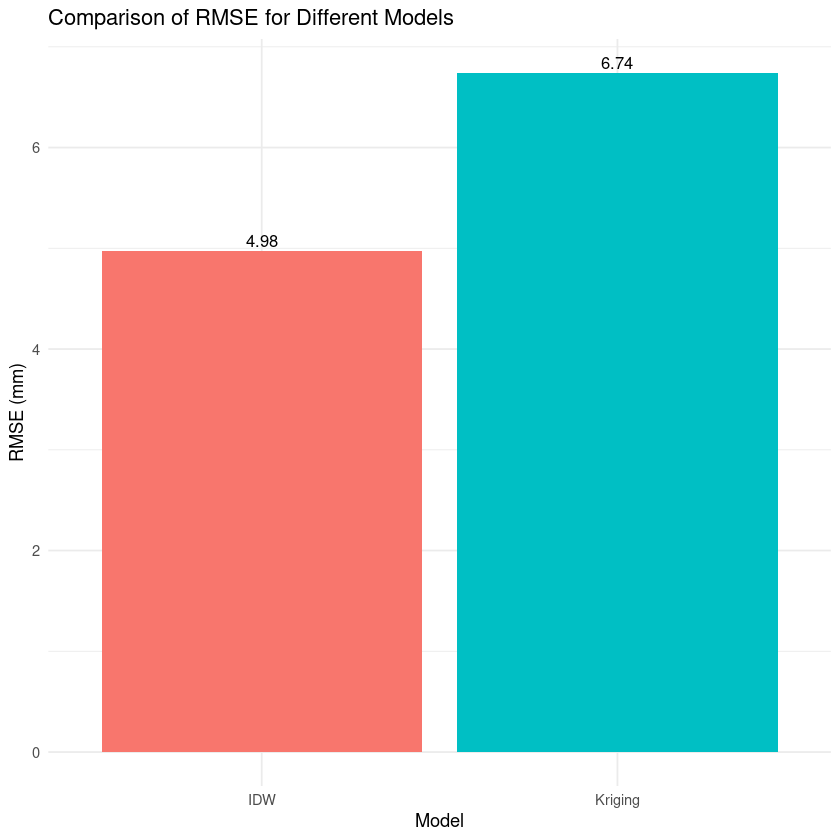

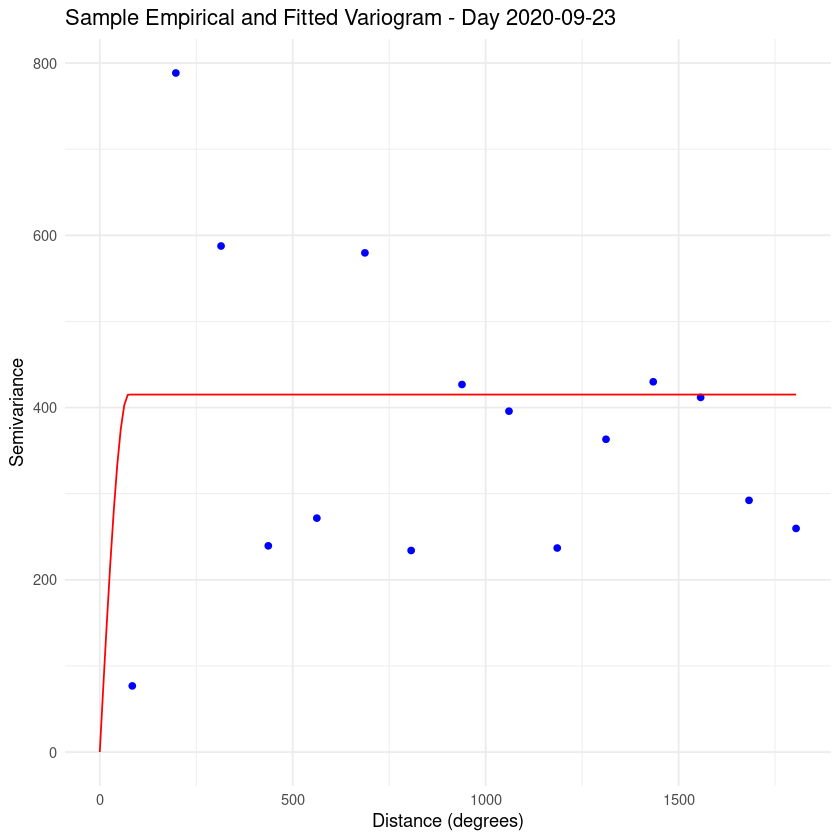

In [149]:
# Combine all daily station predictions into a single data frame for overall evaluation
if (exists("daily_station_predictions_list") && length(daily_station_predictions_list) > 0) {
  all_station_predictions_df <- bind_rows(daily_station_predictions_list, .id = "date_str")
  all_station_predictions_df$date <- as.Date(all_station_predictions_df$date_str)
  print("Combined station predictions (first few rows):")
  print(head(st_drop_geometry(all_station_predictions_df[, c("date", "station_name", "precipitation", "idw_pred_at_station", "kriging_pred_at_station")])))
  
  # --- Scatter Plot: Observed vs. IDW Predicted Precipitation ---
  if ("idw_pred_at_station" %in% names(all_station_predictions_df) && sum(!is.na(all_station_predictions_df$idw_pred_at_station)) > 0) {
    plot_idw_comparison <- ggplot(all_station_predictions_df, aes(x = precipitation, y = idw_pred_at_station)) +
      geom_point(alpha = 0.5) +
      geom_abline(slope = 1, intercept = 0, color = "red") +
      labs(title = "Observed vs. IDW Predicted Precipitation at Stations",
           x = "Observed Precipitation (mm)",
           y = "IDW Predicted Precipitation (mm)") +
      theme_minimal() + 
      coord_fixed(ratio = 1, xlim = range(all_station_predictions_df$precipitation, na.rm=TRUE), ylim = range(all_station_predictions_df$idw_pred_at_station, na.rm=TRUE))
    print(plot_idw_comparison)
  } else { print("Not enough valid IDW prediction data for scatter plot.") }
  
  # --- Scatter Plot: Observed vs. Kriging Predicted Precipitation ---
  if ("kriging_pred_at_station" %in% names(all_station_predictions_df) && sum(!is.na(all_station_predictions_df$kriging_pred_at_station)) > 0) {
    plot_kriging_comparison <- ggplot(all_station_predictions_df, aes(x = precipitation, y = kriging_pred_at_station)) +
      geom_point(alpha = 0.5) +
      geom_abline(slope = 1, intercept = 0, color = "blue") +
      labs(title = "Observed vs. Kriging Predicted Precipitation at Stations",
           x = "Observed Precipitation (mm)",
           y = "Kriging Predicted Precipitation (mm)") +
      theme_minimal() + 
      coord_fixed(ratio = 1, xlim = range(all_station_predictions_df$precipitation, na.rm=TRUE), ylim = range(all_station_predictions_df$kriging_pred_at_station, na.rm=TRUE))
    print(plot_kriging_comparison)
  } else { print("Not enough valid Kriging prediction data for scatter plot.") }
  
  # --- Histograms of Observed and Predicted Precipitation ---
  # Melt data for easier plotting with ggplot
  if (exists("all_station_predictions_df")){
      plot_data_long <- all_station_predictions_df %>% 
          st_drop_geometry() %>%
          select(precipitation, idw_pred_at_station, kriging_pred_at_station) %>%
          pivot_longer(cols = everything(), names_to = "source", values_to = "value") %>%
          filter(!is.na(value))
      
      if(nrow(plot_data_long) > 0) {
          plot_histograms <- ggplot(plot_data_long, aes(x = value, fill = source)) +
          geom_histogram(alpha = 0.7, position = "identity", bins = 30) + # Using identity for overlap, adjust bins as needed
          facet_wrap(~source, scales = "free") + # Separate plots for each source with free scales
          labs(title = "Distribution of Precipitation Values",
               x = "Precipitation (mm)",
               y = "Frequency") +
          theme_minimal() + 
          guides(fill = FALSE) # Hide legend as facets already label the source
          print(plot_histograms)
      } else { print("No data available for histograms.")}
  }
  
  # --- Box Plots of Observed and Predicted Precipitation ---
  if (exists("plot_data_long") && nrow(plot_data_long) > 0) {
      plot_boxplots <- ggplot(plot_data_long, aes(x = source, y = value, fill = source)) +
          geom_boxplot(alpha = 0.7) +
          labs(title = "Distribution of Precipitation Values (Box Plots)",
               x = "Data Source",
               y = "Precipitation (mm)") +
          theme_minimal() +
          guides(fill = FALSE) # Hide legend as x-axis already labels the source
      print(plot_boxplots)
  } else { print("No data available for box plots (plot_data_long not found or empty).") }
  
  # --- Time Series Plots for Sample Stations ---
  if (exists("all_station_predictions_df") && nrow(all_station_predictions_df) > 0) {
    sample_station_names <- unique(all_station_predictions_df$station_name)
    num_stations_to_plot <- min(3, length(sample_station_names)) # Plot for up to 3 stations
    if (num_stations_to_plot > 0) {
      selected_stations_for_ts <- sample(sample_station_names, num_stations_to_plot)
      print(paste("Generating time series plots for stations:", paste(selected_stations_for_ts, collapse=", ")))
      
      ts_plot_data_base <- all_station_predictions_df %>%
        filter(station_name %in% selected_stations_for_ts) %>%
        st_drop_geometry()
      
      # Define base columns that should always exist
      cols_to_select <- c("date", "station_name", "precipitation")
      cols_for_pivot <- c("precipitation")
      
      # Conditionally add prediction columns if they exist in the dataframe
      if ("idw_pred_at_station" %in% names(ts_plot_data_base)) {
        cols_to_select <- c(cols_to_select, "idw_pred_at_station")
        cols_for_pivot <- c(cols_for_pivot, "idw_pred_at_station")
      }
      if ("kriging_pred_at_station" %in% names(ts_plot_data_base)) {
        cols_to_select <- c(cols_to_select, "kriging_pred_at_station")
        cols_for_pivot <- c(cols_for_pivot, "kriging_pred_at_station")
      }
      if ("satellite_precip_at_station" %in% names(ts_plot_data_base)) {
        cols_to_select <- c(cols_to_select, "satellite_precip_at_station")
        cols_for_pivot <- c(cols_for_pivot, "satellite_precip_at_station")
      }
      
      # Ensure cols_for_pivot is not empty before proceeding
      if (length(cols_for_pivot) > 1) { # Greater than 1 because 'precipitation' is always there
          ts_plot_data <- ts_plot_data_base %>%
            select(all_of(cols_to_select)) %>%
            pivot_longer(cols = all_of(cols_for_pivot), 
                         names_to = "data_source", values_to = "precip_value") %>%
            filter(!is.na(precip_value))
      } else {
          # Fallback if only 'precipitation' is available or something went wrong
          ts_plot_data <- ts_plot_data_base %>%
            select(all_of(cols_to_select)) %>% # Should just be date, station_name, precipitation
            rename(precip_value = precipitation) %>%
            mutate(data_source = "precipitation") %>%
            filter(!is.na(precip_value))
      }
      
      if (nrow(ts_plot_data) > 0) {
        plot_time_series <- ggplot(ts_plot_data, aes(x = date, y = precip_value, color = data_source, group = data_source)) +
          geom_line(alpha = 0.8) +
          geom_point(alpha = 0.6, size = 1.5) +
          facet_wrap(~station_name, scales = "free_y") +
          labs(title = "Precipitation Time Series Comparison at Sample Stations",
               x = "Date", y = "Precipitation (mm)", color = "Source") +
          theme_minimal() + 
          theme(axis.text.x = element_text(angle = 45, hjust = 1))
        print(plot_time_series)
      } else { print("No data available for time series plots for the selected stations.") }
    } else { print("No stations available to generate time series plots.") }
  } else { print("Combined station prediction data not available for time series plots.") }
  
  # --- Residual Plots (Observed - Predicted) ---
  if (exists("all_station_predictions_df")) {
    # IDW Residuals
    if ("idw_pred_at_station" %in% names(all_station_predictions_df)) {
      all_station_predictions_df$idw_residuals <- all_station_predictions_df$precipitation - all_station_predictions_df$idw_pred_at_station
      plot_idw_residuals_hist <- ggplot(all_station_predictions_df, aes(x = idw_residuals)) +
        geom_histogram(binwidth = 1, fill = "#FF6F61", color = "black") +
        labs(title = "Histogram of IDW Residuals (Observed - Predicted)", x = "IDW Residuals (mm)", y = "Frequency") +
        theme_minimal()
      print(plot_idw_residuals_hist)
      
      plot_idw_residuals_scatter <- ggplot(all_station_predictions_df, aes(x = idw_pred_at_station, y = idw_residuals)) +
        geom_point(alpha = 0.5, color = "#FF6F61") +
        geom_hline(yintercept = 0, linetype = "dashed") +
        labs(title = "IDW Predicted vs. Residuals", x = "IDW Predicted Precipitation (mm)", y = "IDW Residuals (mm)") +
        theme_minimal()
      print(plot_idw_residuals_scatter)
    } else { print("IDW predictions not available for residual plots.") }
    
    # Kriging Residuals
    if ("kriging_pred_at_station" %in% names(all_station_predictions_df)) {
      all_station_predictions_df$kriging_residuals <- all_station_predictions_df$precipitation - all_station_predictions_df$kriging_pred_at_station
      plot_kriging_residuals_hist <- ggplot(all_station_predictions_df, aes(x = kriging_residuals)) +
        geom_histogram(binwidth = 1, fill = "#6B5B95", color = "black") +
        labs(title = "Histogram of Kriging Residuals (Observed - Predicted)", x = "Kriging Residuals (mm)", y = "Frequency") +
        theme_minimal()
      print(plot_kriging_residuals_hist)
      
      plot_kriging_residuals_scatter <- ggplot(all_station_predictions_df, aes(x = kriging_pred_at_station, y = kriging_residuals)) +
        geom_point(alpha = 0.5, color = "#6B5B95") +
        geom_hline(yintercept = 0, linetype = "dashed") +
        labs(title = "Kriging Predicted vs. Residuals", x = "Kriging Predicted Precipitation (mm)", y = "Kriging Residuals (mm)") +
        theme_minimal()
      print(plot_kriging_residuals_scatter)
    } else { print("Kriging predictions not available for residual plots.") }
  } else { print("Combined station prediction data not available for residual plots.") }
  
  # --- Comparison with Satellite Data ---
  # Ensure satellite data (us_satellite_sf) is available and has the 'date' column
  if (exists("us_satellite_sf") && nrow(us_satellite_sf) > 0 && "date" %in% names(us_satellite_sf)) {
    print("Preparing to extract satellite data at station locations...")
    us_satellite_sf$date <- as.Date(us_satellite_sf$date) # Ensure date format consistency
    
    # Get unique station locations from all_station_predictions_df
    unique_stations_for_satellite_extraction <- all_station_predictions_df %>% 
        distinct(station_name, .keep_all = TRUE) %>% 
        select(station_name, geometry)
    
    # Extract satellite precipitation for each station for each relevant day
    # This is a simplified approach; for many days/stations, a more efficient spatial join or raster sampling is better.
    extracted_satellite_values_list <- list()
    processed_dates_in_stations <- unique(all_station_predictions_df$date)
    
    for(current_eval_date in processed_dates_in_stations) {
        current_eval_date_char <- as.character(current_eval_date)
        daily_sat_data <- us_satellite_sf %>% filter(date == current_eval_date)
        daily_station_locs <- unique_stations_for_satellite_extraction
        
        if(nrow(daily_sat_data) > 0 && nrow(daily_station_locs) > 0) {
            # Find the nearest satellite pixel to each station for that day
            # This is computationally intensive for many points/days. Consider alternatives for large datasets.
            nearest_indices <- st_nearest_feature(daily_station_locs, daily_sat_data)
            extracted_vals_for_day <- daily_sat_data[nearest_indices, ] %>% 
                                      st_drop_geometry() %>%
                                      select(satellite_precipitation)
            daily_station_locs$satellite_precip_at_station <- extracted_vals_for_day$satellite_precipitation
            daily_station_locs$date <- current_eval_date
            extracted_satellite_values_list[[current_eval_date_char]] <- daily_station_locs
        } else { print(paste("No satellite data or station locations for date:", current_eval_date_char)) }
    }
    if (length(extracted_satellite_values_list) > 0) {
        all_satellite_at_stations_df <- bind_rows(extracted_satellite_values_list)
        all_station_predictions_df <- all_station_predictions_df %>% 
            left_join(st_drop_geometry(all_satellite_at_stations_df), by = c("station_name", "date"))
        
        # --- Scatter Plot: Observed vs. Satellite Precipitation ---
        if ("satellite_precip_at_station" %in% names(all_station_predictions_df) && sum(!is.na(all_station_predictions_df$satellite_precip_at_station)) > 0) {
            plot_satellite_comparison <- ggplot(all_station_predictions_df, aes(x = precipitation, y = satellite_precip_at_station)) +
                geom_point(alpha = 0.5) +
                geom_abline(slope = 1, intercept = 0, color = "green") +
                labs(title = "Observed vs. Satellite Precipitation at Stations",
                     x = "Observed Precipitation (mm)",
                     y = "Satellite Precipitation (mm)") +
                theme_minimal() + 
                coord_fixed(ratio = 1, xlim = range(all_station_predictions_df$precipitation, na.rm=TRUE), ylim = range(all_station_predictions_df$satellite_precip_at_station, na.rm=TRUE))
            print(plot_satellite_comparison)
        } else { print("Not enough valid satellite data at station locations for scatter plot.") }
    } else { print("No satellite data could be extracted at station locations for the processed dates.") }
  } else { print("Satellite data (us_satellite_sf) not available or missing 'date' column. Skipping satellite comparison.") }
  
  # --- Calculate and Print Goodness-of-Fit Metrics ---
  print("\n--- Goodness-of-Fit Metrics ---")
  metrics_summary <- list()
  common_data_for_metrics <- all_station_predictions_df %>% st_drop_geometry()
  
  # IDW Metrics
  if ("idw_pred_at_station" %in% names(common_data_for_metrics) && sum(!is.na(common_data_for_metrics$idw_pred_at_station) & !is.na(common_data_for_metrics$precipitation)) > 1) {
    idw_complete_cases <- common_data_for_metrics %>% filter(!is.na(idw_pred_at_station) & !is.na(precipitation))
    if(nrow(idw_complete_cases) > 1) {
        metrics_summary$IDW_RMSE <- hydroGOF::rmse(sim = idw_complete_cases$idw_pred_at_station, obs = idw_complete_cases$precipitation)
        metrics_summary$IDW_MAE <- hydroGOF::mae(sim = idw_complete_cases$idw_pred_at_station, obs = idw_complete_cases$precipitation)
        # R2: Ensure no NA/NaN/Inf in inputs for cor()
        if(all(is.finite(idw_complete_cases$idw_pred_at_station)) && all(is.finite(idw_complete_cases$precipitation)) && var(idw_complete_cases$idw_pred_at_station, na.rm=TRUE) > 0 && var(idw_complete_cases$precipitation, na.rm=TRUE) > 0) {
           metrics_summary$IDW_R2 <- cor(idw_complete_cases$idw_pred_at_station, idw_complete_cases$precipitation)^2
        } else { metrics_summary$IDW_R2 <- NA }
        print(paste("IDW - RMSE:", round(metrics_summary$IDW_RMSE, 3), ", MAE:", round(metrics_summary$IDW_MAE, 3), ", R-squared:", round(metrics_summary$IDW_R2, 3)))
    } else { print("IDW: Not enough complete cases for metrics calculation.") }
  } else { print("IDW predictions not available or insufficient data for metrics.") }
  
  # Kriging Metrics
  if ("kriging_pred_at_station" %in% names(common_data_for_metrics) && sum(!is.na(common_data_for_metrics$kriging_pred_at_station) & !is.na(common_data_for_metrics$precipitation)) > 1) {
    kriging_complete_cases <- common_data_for_metrics %>% filter(!is.na(kriging_pred_at_station) & !is.na(precipitation))
    if(nrow(kriging_complete_cases) > 1) {
        metrics_summary$Kriging_RMSE <- hydroGOF::rmse(sim = kriging_complete_cases$kriging_pred_at_station, obs = kriging_complete_cases$precipitation)
        metrics_summary$Kriging_MAE <- hydroGOF::mae(sim = kriging_complete_cases$kriging_pred_at_station, obs = kriging_complete_cases$precipitation)
        if(all(is.finite(kriging_complete_cases$kriging_pred_at_station)) && all(is.finite(kriging_complete_cases$precipitation)) && var(kriging_complete_cases$kriging_pred_at_station, na.rm=TRUE) > 0 && var(kriging_complete_cases$precipitation, na.rm=TRUE) > 0) {
            metrics_summary$Kriging_R2 <- cor(kriging_complete_cases$kriging_pred_at_station, kriging_complete_cases$precipitation)^2
        } else { metrics_summary$Kriging_R2 <- NA }
        print(paste("Kriging - RMSE:", round(metrics_summary$Kriging_RMSE, 3), ", MAE:", round(metrics_summary$Kriging_MAE, 3), ", R-squared:", round(metrics_summary$Kriging_R2, 3)))
    } else { print("Kriging: Not enough complete cases for metrics calculation.") }
  } else { print("Kriging predictions not available or insufficient data for metrics.") }
  
  # Satellite Metrics
  if ("satellite_precip_at_station" %in% names(common_data_for_metrics) && sum(!is.na(common_data_for_metrics$satellite_precip_at_station) & !is.na(common_data_for_metrics$precipitation)) > 1) {
    satellite_complete_cases <- common_data_for_metrics %>% filter(!is.na(satellite_precip_at_station) & !is.na(precipitation))
    if(nrow(satellite_complete_cases) > 1) {
        metrics_summary$Satellite_RMSE <- hydroGOF::rmse(sim = satellite_complete_cases$satellite_precip_at_station, obs = satellite_complete_cases$precipitation)
        metrics_summary$Satellite_MAE <- hydroGOF::mae(sim = satellite_complete_cases$satellite_precip_at_station, obs = satellite_complete_cases$precipitation)
        if(all(is.finite(satellite_complete_cases$satellite_precip_at_station)) && all(is.finite(satellite_complete_cases$precipitation)) && var(satellite_complete_cases$satellite_precip_at_station, na.rm=TRUE) > 0 && var(satellite_complete_cases$precipitation, na.rm=TRUE) > 0) {
            metrics_summary$Satellite_R2 <- cor(satellite_complete_cases$satellite_precip_at_station, satellite_complete_cases$precipitation)^2
        } else { metrics_summary$Satellite_R2 <- NA }
        print(paste("Satellite - RMSE:", round(metrics_summary$Satellite_RMSE, 3), ", MAE:", round(metrics_summary$Satellite_MAE, 3), ", R-squared:", round(metrics_summary$Satellite_R2, 3)))
    } else { print("Satellite: Not enough complete cases for metrics calculation.") }
  } else { print("Satellite predictions not available or insufficient data for metrics.") }
  
  # --- Bar Plot of RMSE Metrics ---
  if (length(metrics_summary) > 0) {
    rmse_values <- data.frame(
      Model = c(),
      RMSE = c()
    )
    if(!is.null(metrics_summary$IDW_RMSE) && is.finite(metrics_summary$IDW_RMSE)) rmse_values <- rbind(rmse_values, data.frame(Model="IDW", RMSE=metrics_summary$IDW_RMSE))
    if(!is.null(metrics_summary$Kriging_RMSE) && is.finite(metrics_summary$Kriging_RMSE)) rmse_values <- rbind(rmse_values, data.frame(Model="Kriging", RMSE=metrics_summary$Kriging_RMSE))
    if(!is.null(metrics_summary$Satellite_RMSE) && is.finite(metrics_summary$Satellite_RMSE)) rmse_values <- rbind(rmse_values, data.frame(Model="Satellite", RMSE=metrics_summary$Satellite_RMSE))
    
    if(nrow(rmse_values) > 0) {
      plot_rmse_comparison <- ggplot(rmse_values, aes(x = Model, y = RMSE, fill = Model)) +
        geom_bar(stat = "identity") +
        geom_text(aes(label = round(RMSE, 2)), vjust = -0.3, size = 3.5) +
        labs(title = "Comparison of RMSE for Different Models", y = "RMSE (mm)", x = "Model") +
        theme_minimal() + guides(fill=FALSE)
      print(plot_rmse_comparison)
    } else { print("No valid RMSE values to plot.") }
  } else { print("No metrics calculated to plot RMSE comparison.") }
} else { print("Station prediction data (daily_station_predictions_list) not available. Run interpolation step first.") }

# --- Plot Sample Variogram ---
if (!is.null(sample_variogram_empirical) && !is.null(sample_variogram_fitted)) {
  print(paste("Plotting sample variogram from day:", sample_variogram_day))
  variogram_plot <- ggplot(sample_variogram_empirical, aes(x = dist, y = gamma)) +
    geom_point(color = "blue") +
    geom_line(data = variogramLine(sample_variogram_fitted, maxdist = max(sample_variogram_empirical$dist, na.rm=TRUE)), aes(x = dist, y = gamma), color = "red") +
    labs(title = paste("Sample Empirical and Fitted Variogram - Day", sample_variogram_day),
         x = "Distance (degrees)",
         y = "Semivariance") +
    theme_minimal()
  print(variogram_plot)
} else {
  print("No sample variogram was successfully stored during interpolation to plot.")
}

---
## **PS**

*   **Station Coordinates**: Crucially, this notebook uses **DUMMY** coordinates for stations. **Replace with actual station latitude/longitude data for any meaningful spatial analysis.**
*   **Daily Iteration**: The analysis is demonstrated over a selected period. For a full project, interpolation and evaluation should cover all relevant days and potentially different years/seasons.
*   **Variogram Modeling**: Kriging's performance heavily relies on the variogram model. The automated fitting used is a basic approach; careful, possibly manual, variogram analysis is vital for optimal Kriging.
*   **Cross-Validation**: For robust model evaluation, implement proper cross-validation techniques (e.g., k-fold or leave-one-out).
*   **Computational Cost**: Kriging, especially with daily variogram fitting, can be computationally intensive for large datasets and numerous time steps.